# BNET SCPI Smoke Tests

This notebook is for first-pass testing of the custom BNET API/SCPI commands on a Red Pitaya at `169.254.77.151`.

It has two goals:

1. Test that the new BNET SCPI commands are visible and basically functional.
2. Prepare the shape of a later end-to-end butterfly-network test where BNET output is sent to output 1 and captured back on input 1.

Assumptions:

- The board is reachable over Ethernet.
- The custom SCPI server has been compiled, installed, and restarted on the Red Pitaya.
- The matching FPGA bitstream with BNET at `sys[7]` has been loaded.
- For the ASG/acquisition loopback section, physically connect `OUT1` to `IN1` with a coax cable.

In [1]:
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt

# redpitaya_scpi.py is in the same folder as this notebook.
import redpitaya_scpi as scpi

RP_IP = "169.254.77.151"
RP_PORT = 5000
TIMEOUT_S = 5.0

print(f"Notebook ready for Red Pitaya at {RP_IP}:{RP_PORT}")

Notebook ready for Red Pitaya at 169.254.77.151:5000


## Connection Helpers

The low-level `redpitaya_scpi.scpi` object already has `tx_txt()` and `txrx_txt()` methods.

The small wrappers below add logging, so each notebook cell shows exactly which SCPI command was sent and what came back. That is useful while the custom server is still being debugged.

In [2]:
rp = scpi.scpi(RP_IP, timeout=TIMEOUT_S, port=RP_PORT)

def cmd(message: str, check: bool = True) -> None:
    """Send a command that does not return a value.

    Example:
        cmd("BNET:RST")

    SCPI commands ending in `?` are queries and should use `query()` instead.
    """
    print(f">> {message}")
    rp.tx_txt(message)
    if check:
        rp.check_error(stop=False)

def query(message: str, check: bool = True) -> str:
    """Send a query command and return the response text.

    Example:
        status = query("BNET:STATUS?")
    """
    print(f">> {message}")
    response = rp.txrx_txt(message)
    print(f"<< {response}")
    if check:
        rp.check_error(stop=False)
    return response

def query_int(message: str) -> int:
    """Query a command expected to return an integer."""
    return int(query(message).strip())

def clear_errors() -> None:
    """Clear SCPI event/error state and drain the current error queue."""
    cmd("*CLS", check=False)
    for _ in range(16):
        err = query("SYST:ERR:NEXT?", check=False)
        if err.startswith("0,"):
            break

clear_errors()
print(query("*IDN?", check=False))

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> *IDN?
<< REDPITAYA,INSTR2025,,01-21
REDPITAYA,INSTR2025,,01-21


## Command Discovery

Before running BNET-specific tests, check whether the running SCPI server actually contains the new commands.

If this section does not show `BNET:MODE`, `BNET:STREAM#:...`, or `BNET:DDR:...`, then the board is still running an older SCPI server.

In [3]:
def get_command_list() -> list[str]:
    """Return all SCPI command patterns advertised by SYSTem:Help?."""
    help_text = query("SYSTem:Help?", check=False)
    return [line.strip() for line in help_text.splitlines() if line.strip()]

commands = get_command_list()
bnet_commands = [c for c in commands if c.upper().startswith("BNET")]

print(f"Found {len(bnet_commands)} BNET commands:")
for c in bnet_commands:
    print("  ", c)

>> SYSTem:Help?
<< *CLS
*ESE
*ESE?
*ESR?
*IDN?
*OPC
*OPC?
*RST
*SRE
*SRE?
*STB?
*TST?
*WAI
SYSTem:ERRor[:NEXT]?
SYSTem:ERRor:COUNt?
SYSTem:VERSion?
SYSTem:BRD:ID?
SYSTem:BRD:Name?
SYSTem:Help?
STATus:QUEStionable[:EVENt]?
STATus:QUEStionable:ENABle
STATus:QUEStionable:ENABle?
STATus:PRESet
SYSTem:COMMunication:TCPIP:CONTROL?
SYSTem:TIME
SYSTem:TIME?
SYSTem:DATE
SYSTem:DATE?
RP:INit
RP:REset
RP:RELease
RP:DIg[:loop]
RP:LOGmode
RP:RET_ON_ERROR
RP:PLL:ENable
RP:PLL:ENable?
RP:PLL:STATE?
DIG:RST
DIG:PIN
DIG:PIN?
DIG:PIN:DIR
DIG:PIN:DIR?
ANALOG:RST
ANALOG:PIN
ANALOG:PIN?
DAISY:SYNC:TRig
DAISY:SYNC:TRig?
DAISY:SYNC:CLK
DAISY:SYNC:CLK?
DAISY:TRig:Out:ENable
DAISY:TRig:Out:ENable?
DAISY:TRig:Out:SOUR
DAISY:TRig:Out:SOUR?
ACQ:START
ACQ:START:CH#
ACQ:STOP
ACQ:STOP:CH#
ACQ:RST
ACQ:RST:CH#
ACQ:SPLIT:TRig
ACQ:SPLIT:TRig?
ACQ:DEC
ACQ:DEC:CH#
ACQ:DEC?
ACQ:DEC:CH#?
ACQ:DEC:Factor
ACQ:DEC:Factor:CH#
ACQ:DEC:Factor?
ACQ:DEC:Factor:CH#?
ACQ:SRATe?
ACQ:SRATe:CH#?
ACQ:AVG
ACQ:AVG?
ACQ:AVG:CH#
ACQ:AVG:CH#?


## Basic BNET Scalar Register Test

This is the simplest test. It does not require DDR, ADC, or DAC.

The scalar/debug BNET block has eight input registers and four output registers. The early debug behavior is:

- `OUT0 = CH0 + CH1`
- `OUT1 = CH2 + CH3`
- `OUT2 = CH4 + CH5`
- `OUT3 = CH6 + CH7`

If this test fails, start with register mapping, API mapping, or SCPI handler debugging before testing DDR streams.

In [4]:
def bnet_scalar_smoke_test() -> None:
    """Exercise the old scalar/debug BNET path.

    This checks that:
    - the BNET sys-bus register block is mapped,
    - SCPI can write BNET channel registers,
    - BNET:START reaches hardware,
    - output registers can be read back.
    """
    clear_errors()
    cmd("BNET:RST")
    cmd("BNET:CH0:DATA 10")
    cmd("BNET:CH1:DATA 32")
    cmd("BNET:CH2:DATA -7")
    cmd("BNET:CH3:DATA 3")
    cmd("BNET:START")

    status = query_int("BNET:STATUS?")
    out0 = query_int("BNET:OUT0:DATA?")
    out1 = query_int("BNET:OUT1:DATA?")

    print("BNET status:", status)
    print("OUT0 should be 42 ->", out0)
    print("OUT1 should be -4 ->", out1)

    assert out0 == 42, f"Expected OUT0=42, got {out0}"
    assert out1 == -4, f"Expected OUT1=-4, got {out1}"

bnet_scalar_smoke_test()

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:RST
>> BNET:CH0:DATA 10
>> BNET:CH1:DATA 32
>> BNET:CH2:DATA -7
>> BNET:CH3:DATA 3
>> BNET:START
>> BNET:STATUS?
<< 2
>> BNET:OUT0:DATA?
<< 42
>> BNET:OUT1:DATA?
<< -4
BNET status: 2
OUT0 should be 42 -> 42
OUT1 should be -4 -> -4


## BNET Stream Register Probe

This section checks the new register wrappers without requiring a real DDR transfer.

The important idea:

- `BNET:MODE` selects input source: `ASG`, `ADC`, or `DDR`.
- `BNET:VLEN` tells hardware how many samples belong to a vector.
- `BNET:STREAM#:...` configures one DDR stream descriptor.
- `BNET:STREAM#:COMMIT#` marks a ping/pong buffer as ready for hardware to use.

In [5]:
def bnet_stream_register_probe() -> None:
    """Probe BNET stream descriptor commands.

    This is a register-level test. It does not prove AXI reads work yet.
    It only proves that the SCPI server can write/read the stream descriptor registers.
    """
    clear_errors()
    cmd("BNET:RST")

    for mode in ["ASG", "ADC", "DDR"]:
        cmd(f"BNET:MODE {mode}")
        observed = query("BNET:MODE?")
        print(f"Mode set/readback: requested={mode}, observed={observed}")

    cmd("BNET:VLEN 16")
    assert query_int("BNET:VLEN?") == 16

    stream_count = query_int("BNET:STREAM:COUNT?")
    print("Hardware reports stream count:", stream_count)

    # Write obvious dummy values into stream 0 descriptor registers.
    # These addresses are not used for a real transfer in this probe.
    cmd("BNET:STREAM0:BASE0 268435456")
    cmd("BNET:STREAM0:LENGTH 128")
    cmd("BNET:STREAM0:STRIDE 2")
    cmd("BNET:STREAM0:FORMAT 0")
    cmd("BNET:STREAM0:ENABLE 1")

    print("BASE0 =", query_int("BNET:STREAM0:BASE0?"))
    print("LENGTH =", query_int("BNET:STREAM0:LENGTH?"))
    print("STRIDE =", query_int("BNET:STREAM0:STRIDE?"))
    print("FORMAT =", query_int("BNET:STREAM0:FORMAT?"))
    print("ENABLE =", query_int("BNET:STREAM0:ENABLE?"))
    print("STATUS =", query_int("BNET:STREAM0:STATUS?"))
    print("READ_PTR =", query_int("BNET:STREAM0:RPTR?"))

bnet_stream_register_probe()

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> BNET:RST
>> BNET:MODE ASG
>> BNET:MODE?
<< ASG
Mode set/readback: requested=ASG, observed=ASG
>> BNET:MODE ADC
>> BNET:MODE?
<< ADC
Mode set/readback: requested=ADC, observed=ADC
>> BNET:MODE DDR
>> BNET:MODE?
<< DDR
Mode set/readback: requested=DDR, observed=DDR
>> BNET:VLEN 16
>> BNET:VLEN?
<< 16
>> BNET:STREAM:COUNT?
<< 8
Hardware reports stream count: 8
>> BNET:STREAM0:BASE0 268435456
>> BNET:STREAM0:LENGTH 128
>> BNET:STREAM0:STRIDE 2
>> BNET:STREAM0:FORMAT 0
>> BNET:STREAM0:ENABLE 1
>> BNET:STREAM0:BASE0?
<< 268435456
BASE0 = 268435456
>> BNET:STREAM0:LENGTH?
<< 128
LENGTH = 128
>> BNET:STREAM0:STRIDE?
<< 2
STRIDE = 2
>> BNET:STREAM0:FORMAT?
<< 0
FORMAT = 0
>> BNET:STREAM0:ENABLE?
<< 1
ENABLE = 1
>> BNET:STREAM0:STATUS?
<< 4
STATUS = 4
>> BNET:STREAM0:RPTR?
<< 0
READ_PTR = 0


## Fixed-Point Packing Helpers

BNET weights should be sent as fixed-point integers, not floats.

Example Q1.14 format:

- real `+0.5` becomes integer `8192`
- real `-0.25` becomes integer `-4096`
- hardware later interprets the integer by dividing by `2^14`

The SCPI byte-upload command currently accepts comma-separated bytes. So the helper below converts an `int16` NumPy array into little-endian bytes, then into a SCPI-safe comma-separated byte string.

In [6]:
def quantize_q14(values: np.ndarray) -> np.ndarray:
    """Convert float weights/samples into signed Q1.14 int16 values.

    Q1.14 means 14 fractional bits. The representable range is roughly
    [-2.0, +1.9999], but for neural/network weights we usually keep values
    inside [-1.0, +1.0] to avoid overflow in later multiply/add stages.
    """
    scaled = np.rint(np.asarray(values, dtype=np.float64) * (1 << 14))
    clipped = np.clip(scaled, -32768, 32767)
    return clipped.astype("<i2")

def pack_i16_le(values: np.ndarray) -> bytes:
    """Pack signed 16-bit values as little-endian raw bytes for BNET DDR upload."""
    return np.asarray(values, dtype="<i2").tobytes()

def bytes_to_scpi_csv(data: bytes) -> str:
    """Convert bytes into the comma-separated decimal format parsed by SCPI_ParamBufferUInt8."""
    return ",".join(str(b) for b in data)

def reserve_bnet_slot(slot: int, address: int, size_bytes: int) -> None:
    """Reserve a software DDR slot for BNET uploads.

    The address must be inside the OS-reserved AXI memory region. The size must
    be a multiple of 0x80 bytes because the current API follows the generator
    AXI reservation convention.
    """
    cmd(f"BNET:DDR:SLOT{slot}:RESERVE {address},{size_bytes}")

def upload_bnet_slot_bytes(slot: int, offset_bytes: int, data: bytes) -> None:
    """Upload raw bytes to a BNET DDR slot.

    The command pattern is:
        BNET:DDR:SLOT#:OFFSET#:DATA# <byte0>,<byte1>,...

    The final # in DATA# is the number of bytes expected by the SCPI handler.
    """
    payload = bytes_to_scpi_csv(data)
    cmd(f"BNET:DDR:SLOT{slot}:OFFSET{offset_bytes}:DATA{len(data)} {payload}")

def attach_slot_to_stream(slot: int, stream: int, buffer: int) -> None:
    """Wire a reserved DDR slot into one BNET hardware stream ping/pong buffer.

    This sets the stream BASE register and LENGTH register from the slot.
    buffer=0 means ping/BASE0. buffer=1 means pong/BASE1.
    """
    cmd(f"BNET:DDR:SLOT{slot}:STREAM{stream}:BUF{buffer}")

def spaced_slot_address(ddr_start: int, slot_index: int, slot_size_bytes: int) -> int:
    """Return a conservative DDR slot address for BNET tests.

    The AXI memory reservation helper can reject immediately-adjacent blocks as
    overlapping. Spacing test slots by two slot sizes leaves a guard gap between
    reservations, which makes the streaming smoke test less sensitive to that
    boundary-condition behavior.
    """
    return ddr_start + slot_index * 2 * slot_size_bytes

# Quick demonstration of fixed-point packing.
demo_float = np.array([0.0, 0.5, -0.25, 1.0], dtype=np.float64)
demo_q14 = quantize_q14(demo_float)
print("float:", demo_float)
print("Q1.14 int16:", demo_q14)
print("little-endian bytes:", list(pack_i16_le(demo_q14)))

float: [ 0.    0.5  -0.25  1.  ]
Q1.14 int16: [    0  8192 -4096 16384]
little-endian bytes: [0, 0, 0, 32, 0, 240, 0, 64]


## Optional DDR Slot Smoke Test

Run this only after the custom API and SCPI server are deployed.

This test reserves two tiny DDR slots:

- slot 0: input samples for BNET stream 0
- slot 1: fixed-point weights for BNET stream 1

It then attaches the slots to BNET stream buffers and commits them. This checks the software path up to descriptor setup. It does not yet prove the final network output is correct.

In [ ]:
def bnet_ddr_slot_smoke_test(vector_len: int = 16, slot_size_bytes: int = 128) -> None:
    """Reserve DDR, upload data, attach two streams, start BNET, and check progress.

    slot_size_bytes defaults to 128 because the BNET DDR API currently requires
    0x80-byte alignment. The actual data payload can be shorter than the slot.
    """
    clear_errors()

    ddr_start = query_int("BNET:DDR:START?")
    ddr_size = query_int("BNET:DDR:SIZE?")
    print(f"OS-reserved DDR region: start=0x{ddr_start:08x}, size={ddr_size} bytes")

    slot0_addr = spaced_slot_address(ddr_start, 0, slot_size_bytes)
    slot1_addr = spaced_slot_address(ddr_start, 1, slot_size_bytes)
    assert slot1_addr + slot_size_bytes <= ddr_start + ddr_size, "Not enough reserved DDR for test slots"
    print(f"Slot 0 address: 0x{slot0_addr:08x}")
    print(f"Slot 1 address: 0x{slot1_addr:08x}")

    # Example input samples and weights. These are intentionally tiny and obvious.
    # For now, this is a data-path smoke test rather than a network-correctness test.
    input_samples = np.arange(vector_len, dtype="<i2")
    weights = quantize_q14(np.linspace(-0.5, 0.5, vector_len))

    cmd("BNET:RST")
    reserve_bnet_slot(0, slot0_addr, slot_size_bytes)
    reserve_bnet_slot(1, slot1_addr, slot_size_bytes)

    upload_bnet_slot_bytes(0, 0, pack_i16_le(input_samples))
    upload_bnet_slot_bytes(1, 0, pack_i16_le(weights))

    attach_slot_to_stream(0, stream=0, buffer=0)
    attach_slot_to_stream(1, stream=1, buffer=0)

    cmd(f"BNET:VLEN {vector_len}")
    cmd("BNET:STREAM0:FORMAT 0")
    cmd("BNET:STREAM1:FORMAT 0")
    cmd("BNET:STREAM0:ENABLE 1")
    cmd("BNET:STREAM1:ENABLE 1")
    cmd("BNET:STREAM0:COMMIT0")
    cmd("BNET:STREAM1:COMMIT0")
    cmd("BNET:MODE DDR")

    assert query("BNET:MODE?") == "DDR"
    assert query_int("BNET:VLEN?") == vector_len
    assert query_int("BNET:STREAM0:BASE0?") == slot0_addr
    assert query_int("BNET:STREAM1:BASE0?") == slot1_addr
    assert query_int("BNET:STREAM0:LENGTH?") == slot_size_bytes
    assert query_int("BNET:STREAM1:LENGTH?") == slot_size_bytes

    rptr0_before = query_int("BNET:STREAM0:RPTR?")
    rptr1_before = query_int("BNET:STREAM1:RPTR?")
    pending_before = query_int("BNET:PENDING?")
    error_before = query_int("BNET:ERROR?")
    print(f"Before START: pending=0x{pending_before:x}, error=0x{error_before:x}, rptr0={rptr0_before}, rptr1={rptr1_before}")
    assert error_before == 0, "BNET reported an error before START"
    assert pending_before & 0x3 == 0x3, "Both stream 0 and stream 1 should have pending buffers before START"

    cmd("BNET:START")
    time.sleep(0.05)

    active_after = query_int("BNET:ACTIVE?")
    pending_after = query_int("BNET:PENDING?")
    error_after = query_int("BNET:ERROR?")
    status0_after = query_int("BNET:STREAM0:STATUS?")
    status1_after = query_int("BNET:STREAM1:STATUS?")
    rptr0_after = query_int("BNET:STREAM0:RPTR?")
    rptr1_after = query_int("BNET:STREAM1:RPTR?")

    print(f"After START: active=0x{active_after:x}, pending=0x{pending_after:x}, error=0x{error_after:x}")
    print(f"Stream 0: status=0x{status0_after:x}, rptr {rptr0_before} -> {rptr0_after}")
    print(f"Stream 1: status=0x{status1_after:x}, rptr {rptr1_before} -> {rptr1_after}")

    assert error_after == 0, "BNET reported a stream error after START"
    assert (rptr0_after != rptr0_before) or (pending_after & 0x1) == 0, "Stream 0 did not appear to consume its pending buffer"
    assert (rptr1_after != rptr1_before) or (pending_after & 0x2) == 0, "Stream 1 did not appear to consume its pending buffer"

# Uncomment after the new SCPI server is installed and the matching FPGA bitstream is loaded.
bnet_ddr_slot_smoke_test()

## ASG Output 1 to Acquisition Input 1 Loopback

This is a standard Red Pitaya sanity test, independent of BNET.

Purpose:

- Confirm SCPI generator commands work.
- Confirm SCPI acquisition commands work.
- Confirm the physical cable from `OUT1` to `IN1` is correct.

Hardware setup:

- Connect `OUT1` to `IN1`.
- Start with low amplitude, for example `0.2 V`, to avoid clipping or accidental high input levels.

Later, once BNET output is routed into the DAC/output path, this same acquisition skeleton can be used to capture the computed BNET output.

>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> GEN:RST
>> SOUR1:FUNC SINE
>> SOUR1:FREQ:FIX 10000
>> SOUR1:VOLT 0.2
>> SOUR1:VOLT:OFFS 0
>> OUTPUT1:STATE ON
>> *CLS
>> SYST:ERR:NEXT?
<< 0,"No error"
>> ACQ:RST
>> ACQ:DATA:Units VOLTS
>> ACQ:DATA:FORMAT ASCII
>> ACQ:DEC 1
>> ACQ:AVG ON
>> ACQ:TRig:DLY 0
>> ACQ:TRig:LEV 0
>> ACQ:START
>> ACQ:TRig NOW
>> ACQ:TRig:STAT?
<< TD
Trigger state: TD
>> ACQ:STOP
>> OUTPUT1:STATE OFF


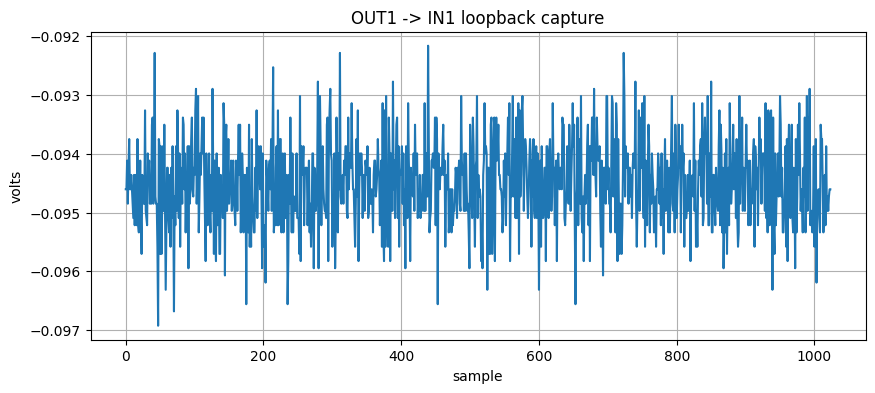

In [8]:
def parse_scpi_ascii_array(text: str) -> np.ndarray:
    """Parse Red Pitaya ASCII array responses like '{0.1,0.2,...}'."""
    cleaned = text.strip().strip("{}").replace(" ", "")
    if not cleaned:
        return np.array([], dtype=np.float64)
    return np.array([float(x) for x in cleaned.split(",") if x], dtype=np.float64)

def wait_for_trigger(timeout_s: float = 3.0) -> str:
    """Poll acquisition trigger state until triggered or timeout."""
    deadline = time.time() + timeout_s
    last = ""
    while time.time() < deadline:
        last = query("ACQ:TRig:STAT?", check=False)
        if last.upper().startswith("TD"):
            return last
        time.sleep(0.05)
    return last

def acquire_input1_latest(samples: int = 1024) -> np.ndarray:
    """Acquire the newest voltage samples from input channel 1.

    This helper does not configure the generator. That matters for the later
    BNET test, where output 1 should come from BNET hardware rather than a
    freshly configured ASG sine wave.
    """
    clear_errors()
    cmd("ACQ:RST")

    # Acquisition setup: return voltage samples as readable ASCII for now.
    cmd("ACQ:DATA:Units VOLTS")
    cmd("ACQ:DATA:FORMAT ASCII")
    cmd("ACQ:DEC 1")
    cmd("ACQ:AVG ON")
    cmd("ACQ:TRig:DLY 0")
    cmd("ACQ:TRig:LEV 0")

    cmd("ACQ:START")
    time.sleep(0.1)
    cmd("ACQ:TRig NOW")
    trig_state = wait_for_trigger()
    print("Trigger state:", trig_state)

    # Get the newest samples from input channel 1.
    rp.tx_txt(f"ACQ:SOUR1:DATA:LATest:N? {samples}")
    data_text = rp.rx_txt()
    rp.check_error(stop=False)
    data = parse_scpi_ascii_array(data_text)

    cmd("ACQ:STOP")
    return data

def asg_to_acq_loopback(freq_hz: float = 10_000, amplitude_v: float = 0.2, samples: int = 1024) -> np.ndarray:
    """Generate a sine on OUT1 and acquire it from IN1.

    This is not a BNET test yet. It is the analog I/O checkout that confirms
    the generator, acquisition, and OUT1-to-IN1 cable are all working.
    """
    clear_errors()
    cmd("GEN:RST")

    # Generator setup: produce a safe sine wave on output channel 1.
    cmd("SOUR1:FUNC SINE")
    cmd(f"SOUR1:FREQ:FIX {freq_hz}")
    cmd(f"SOUR1:VOLT {amplitude_v}")
    cmd("SOUR1:VOLT:OFFS 0")
    cmd("OUTPUT1:STATE ON")

    data = acquire_input1_latest(samples=samples)
    cmd("OUTPUT1:STATE OFF")
    return data

# Uncomment when OUT1 is physically connected to IN1.
captured = asg_to_acq_loopback()
plt.figure(figsize=(10, 4))
plt.plot(captured)
plt.title("OUT1 -> IN1 loopback capture")
plt.xlabel("sample")
plt.ylabel("volts")
plt.grid(True)
plt.show()

## Later: Proper BNET Output Capture Test

This is the planned test once the FPGA data path is ready to route BNET output into the DAC/output path.

High-level plan:

1. Quantize known input vector and known weights on the PC.
2. Upload input vector to BNET DDR slot 0.
3. Upload weights to BNET DDR slot 1.
4. Attach slot 0 to BNET stream 0 and slot 1 to BNET stream 1.
5. Set `BNET:MODE DDR`.
6. Start BNET.
7. Route BNET output to DAC/output 1 in hardware.
8. Physically loop `OUT1` into `IN1`.
9. Use acquisition commands to capture the computed waveform/result.
10. Compare captured data against the expected PC-side fixed-point/network result.

The exact route command may not exist yet. If routing is purely in FPGA hardware, this notebook only needs the BNET setup plus standard `ACQ:*` capture commands.

In [ ]:
def future_bnet_to_output1_capture_test():
    """Skeleton for the final BNET hardware test.

    This is intentionally not run yet. It documents the intended test flow and
    gives us a place to fill in the final routing details once the bitstream and
    SCPI server are both ready.
    """
    vector_len = 16
    slot_size_bytes = 128

    # 1. Create deterministic test data on the PC.
    input_float = np.linspace(-0.75, 0.75, vector_len)
    weight_float = np.ones(vector_len) * 0.5
    input_q14 = quantize_q14(input_float)
    weight_q14 = quantize_q14(weight_float)

    # 2. Upload fixed-point data into DDR and attach to BNET streams.
    ddr_start = query_int("BNET:DDR:START?")
    slot0_addr = spaced_slot_address(ddr_start, 0, slot_size_bytes)
    slot1_addr = spaced_slot_address(ddr_start, 1, slot_size_bytes)
    reserve_bnet_slot(0, slot0_addr, slot_size_bytes)
    reserve_bnet_slot(1, slot1_addr, slot_size_bytes)
    upload_bnet_slot_bytes(0, 0, pack_i16_le(input_q14))
    upload_bnet_slot_bytes(1, 0, pack_i16_le(weight_q14))
    attach_slot_to_stream(0, stream=0, buffer=0)
    attach_slot_to_stream(1, stream=1, buffer=0)

    # 3. Configure BNET stream mode.
    cmd(f"BNET:VLEN {vector_len}")
    cmd("BNET:STREAM0:FORMAT 0")
    cmd("BNET:STREAM1:FORMAT 0")
    cmd("BNET:STREAM0:ENABLE 1")
    cmd("BNET:STREAM1:ENABLE 1")
    cmd("BNET:STREAM0:COMMIT0")
    cmd("BNET:STREAM1:COMMIT0")
    cmd("BNET:MODE DDR")

    # 4. TODO: Add or confirm the hardware route from BNET result to DAC/output 1.
    # This may be automatic in the FPGA bitstream, or may need a future SCPI/API control.

    # 5. Start BNET and acquire the output from IN1.
    cmd("BNET:START")
    captured = acquire_input1_latest(samples=1024)
    return captured

# captured_bnet = future_bnet_to_output1_capture_test()

## Cleanup

Run this at the end of a session to leave the generator output off and close the socket cleanly.

In [ ]:
def cleanup():
    """Turn off output 1, stop acquisition, and close the SCPI socket."""
    try:
        cmd("OUTPUT1:STATE OFF", check=False)
        cmd("ACQ:STOP", check=False)
    finally:
        rp.close()

# cleanup()